In [41]:
!pip install pandas


In [42]:
import pandas as pd
import os
path = "/Users/faatinashahul/Desktop/ml/hand"          
img = os.path.join(path, "Img")
csv = os.path.join(path, "english.csv")

df = pd.read_csv(csv, encoding='latin1')
print(df.head(5))
print(df.tail(5))


                image label
0  Img/img001-001.png     0
1  Img/img001-002.png     0
2  Img/img001-003.png     0
3  Img/img001-004.png     0
4  Img/img001-005.png     0
                   image label
3405  Img/img062-051.png     z
3406  Img/img062-052.png     z
3407  Img/img062-053.png     z
3408  Img/img062-054.png     z
3409  Img/img062-055.png     z


In [43]:
!pip install opencv-python

In [44]:
df.iloc[0]['image']


'Img/img001-001.png'

In [57]:
import cv2
import numpy as np
x = []
y = []

for _, row in df.iterrows():
    label = str(row['label'])
    if label not in ["z", "y"]:
        continue
    image_path = os.path.join(path, row['image'])
    img_data = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    resized_img = cv2.resize(img_data, (28, 28))
    
    resized_img = resized_img / 255.0
    resized_img = resized_img.flatten()
    x.append(resized_img)
    if label == "z":
        y.append(1)
    else:   # y
        y.append(-1)
x = np.array(x)
y = np.array(y)
print("Dataset:", x.shape, y.shape)


Dataset: (110, 784) (110,)


In [58]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Accuracy : 0.5
Precision: 0.5333333333333333
Recall   : 0.6666666666666666
F1-score : 0.5925925925925926
Confusion Matrix:
 [[3 7]
 [4 8]]


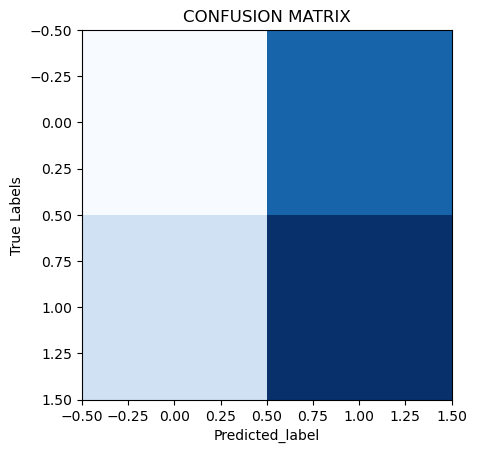

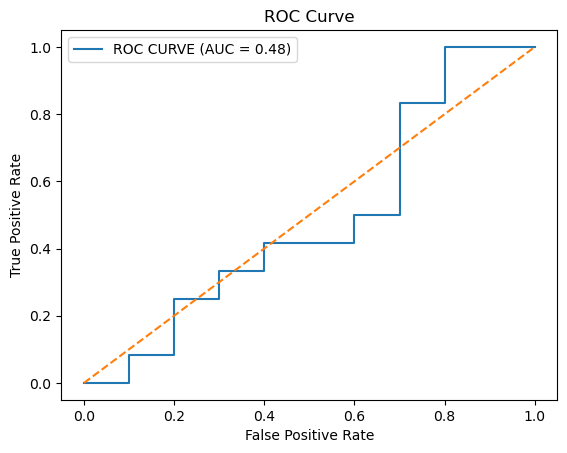

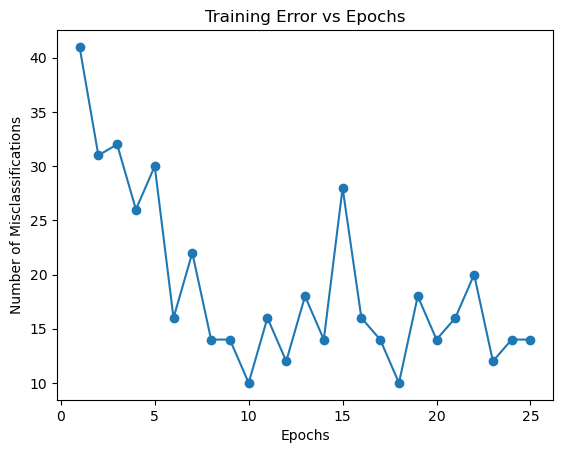

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,confusion_matrix,roc_curve,auc
class Perception:
    def __init__(self,lrate,epochs):
        self.lr=lrate
        self.epochs=epochs

    def step_function(self,z):
        return np.where(z>=0,1,-1)

    def fit(self,x,y):
        self.weights=np.zeros(x.shape[1])
        self.bias=0
        self.errors=[]

        for e in range(self.epochs):
            error_count=0
            for i in range(len(x)):
                z=np.dot(x[i],self.weights)+self.bias
                y_pred=self.step_function(z)

                if(y_pred!=y[i]):
                    self.weights+=self.lr*y[i]*x[i]
                    self.bias+=self.lr*y[i]
                    error_count+=1
            self.errors.append(error_count)
                    

    def predict(self,y_test):
         z=np.dot(y_test,self.weights)+self.bias
         return self.step_function(z)
    
        
pla=Perception(lrate=0.01,epochs=25)
pla.fit(x_train,y_train)
y_pred=pla.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.imshow(cm,cmap="Blues")
plt.title("CONFUSION MATRIX")
plt.xlabel("Predicted_label")
plt.ylabel("True Labels")
plt.show()

scores=np.dot(x_test,pla.weights)+pla.bias
fpr,tpr,t=roc_curve(y_test,scores)
roc=auc(fpr,tpr)
plt.plot(fpr,tpr,label="ROC CURVE (AUC = %.2f)"%roc)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

plt.plot(range(1,(len(pla.errors)+1)),pla.errors,marker='o')
plt.xlabel("Epochs")
plt.ylabel("Number of Misclassifications")
plt.title("Training Error vs Epochs")
plt.show()


In [81]:

    
# ---------------- MLP ----------------
from sklearn.neural_network import MLPClassifier

mlp_configs = [
    {"hidden_layer_sizes": (256, 128), "activation": "relu", "solver": "adam", "lr": 0.001, "batch_size": 32},
    {"hidden_layer_sizes": (256, 128), "activation": "relu", "solver": "adam", "lr": 0.001, "batch_size": 64},
    {"hidden_layer_sizes": (256, 128), "activation": "relu", "solver": "sgd",  "lr": 0.001, "batch_size": 32},
    {"hidden_layer_sizes": (256, 128), "activation": "tanh", "solver": "adam", "lr": 0.001, "batch_size": 32},
]

mlp_results = []

for cfg in mlp_configs:
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg["hidden_layer_sizes"],
        activation=cfg["activation"],
        solver=cfg["solver"],
        learning_rate_init=cfg["lr"],
        batch_size=cfg["batch_size"],
        max_iter=100,
        random_state=42,
    )

    mlp.fit(x_train, y_train)
    y_pred_mlp = mlp.predict(x_test)

    mlp_results.append({
        "Accuracy": accuracy_score(y_test, y_pred_mlp),
        "Precision": precision_score(y_test, y_pred_mlp, average='macro'),
        "Recall": recall_score(y_test, y_pred_mlp, average='macro'),
        "F1-score": f1_score(y_test, y_pred_mlp, average='macro'),
        "Model": mlp
    })

# Best MLP
best_mlp = mlp_results[np.argmax([r["Accuracy"] for r in mlp_results])]

# ROC Curve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

y_test_bin = LabelBinarizer().fit_transform(y_test)
y_score = best_mlp["Model"].predict_proba(x_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MLP ROC Curve")
plt.show()


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classif

NameError: name 'classes' is not defined

In [92]:
import pandas as pd
import numpy as np
import os
import cv2

path = "/Users/faatinashahul/Desktop/ml/hand"
csv_path = os.path.join(path, "english.csv")

df = pd.read_csv(csv_path, encoding="latin1")

print("Total samples:", len(df))
print("Unique classes:", df["label"].nunique())
IMG_SIZE = 28

X = []
Y = []

for _, row in df.iterrows():

    img_path = os.path.join(path, row["image"])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = img.flatten()

    X.append(img)
    Y.append(row["label"])

X = np.array(X)
Y = np.array(Y)

print("Dataset shape:", X.shape, Y.shape)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
Y_encoded = le.fit_transform(Y)

classes = le.classes_

print("Classes:", classes)
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=Y_encoded
)


Total samples: 3410
Unique classes: 62
Dataset shape: (3410, 784) (3410,)
Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z'
 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']


In [96]:
class Perceptron:

    def __init__(self, lr=0.01, epochs=25):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):

        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for _ in range(self.epochs):
            for xi, yi in zip(X, y):

                z = np.dot(xi, self.weights) + self.bias
                pred = 1 if z >= 0 else 0

                self.weights += self.lr * (yi - pred) * xi
                self.bias += self.lr * (yi - pred)

    def score(self, X):
        return np.dot(X, self.weights) + self.bias


# -------- Train One-vs-Rest --------
pla_models = []

for cls in np.unique(Y_train):

    y_binary = np.where(Y_train == cls, 1, 0)

    model = Perceptron()
    model.fit(X_train, y_binary)

    pla_models.append(model)


def pla_predict(X):

    scores = []

    for model in pla_models:
        scores.append(model.score(X))

    scores = np.array(scores)

    return np.argmax(scores, axis=0)


Y_pred_pla = pla_predict(X_test)


In [98]:
# ================= MLP HYPERPARAMETER EXPERIMENT =================

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# -------- Hyperparameter configurations --------
mlp_configs = [

    # Config 1
    {
        "hidden_layers": (128,),
        "activation": "relu",
        "solver": "adam",
        "learning_rate": 0.001,
        "batch_size": 32
    },

    # Config 2
    {
        "hidden_layers": (256,128),
        "activation": "relu",
        "solver": "adam",
        "learning_rate": 0.001,
        "batch_size": 32
    },

    # Config 3
    {
        "hidden_layers": (256,128),
        "activation": "tanh",
        "solver": "adam",
        "learning_rate": 0.001,
        "batch_size": 32
    },

    # Config 4
    {
        "hidden_layers": (256,128),
        "activation": "relu",
        "solver": "sgd",
        "learning_rate": 0.001,
        "batch_size": 32
    },

    # Config 5
    {
        "hidden_layers": (256,128),
        "activation": "tanh",
        "solver": "adam",
        "learning_rate": 0.0005,
        "batch_size": 64
    },

    # Config 6
    {
        "hidden_layers": (512,256),
        "activation": "relu",
        "solver": "adam",
        "learning_rate": 0.001,
        "batch_size": 16
    },
]

# -------- Store results --------
results = []

for i, cfg in enumerate(mlp_configs):

    print(f"\nTraining MLP Configuration {i+1}")

    mlp = MLPClassifier(

        hidden_layer_sizes = cfg["hidden_layers"],
        activation = cfg["activation"],
        solver = cfg["solver"],
        learning_rate_init = cfg["learning_rate"],
        batch_size = cfg["batch_size"],
        max_iter = 300,
        early_stopping = True,
        random_state = 42,
        verbose = False
    )

    # Train
    mlp.fit(X_train, Y_train)

    # Predict
    Y_pred = mlp.predict(X_test)

    # Metrics
    acc  = accuracy_score(Y_test, Y_pred)
    prec = precision_score(Y_test, Y_pred, average="macro")
    rec  = recall_score(Y_test, Y_pred, average="macro")
    f1   = f1_score(Y_test, Y_pred, average="macro")

    results.append({

        "Hidden Layers": cfg["hidden_layers"],
        "Activation": cfg["activation"],
        "Optimizer": cfg["solver"],
        "Learning Rate": cfg["learning_rate"],
        "Batch Size": cfg["batch_size"],
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "Model": mlp
    })

# -------- Convert to DataFrame --------
results_df = pd.DataFrame(results)

print("\nAll MLP Configurations Performance:\n")
print(results_df.drop(columns="Model"))



Training MLP Configuration 1


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Training MLP Configuration 2

Training MLP Configuration 3


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Training MLP Configuration 4


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Training MLP Configuration 5

Training MLP Configuration 6

All MLP Configurations Performance:

  Hidden Layers Activation Optimizer  Learning Rate  Batch Size  Accuracy  \
0        (128,)       relu      adam         0.0010          32  0.016129   
1    (256, 128)       relu      adam         0.0010          32  0.378299   
2    (256, 128)       tanh      adam         0.0010          32  0.224340   
3    (256, 128)       relu       sgd         0.0010          32  0.325513   
4    (256, 128)       tanh      adam         0.0005          64  0.359238   
5    (512, 256)       relu      adam         0.0010          16  0.021994   

   Precision    Recall  F1-score  
0   0.000591  0.016129  0.001141  
1   0.431050  0.378299  0.373221  
2   0.227101  0.224340  0.197220  
3   0.358585  0.325513  0.318353  
4   0.405733  0.359238  0.354119  
5   0.000835  0.021994  0.001586  


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [85]:
from sklearn.metrics import confusion_matrix

def evaluate(name, y_true, y_pred):

    print(f"\n{name} PERFORMANCE")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_true, y_pred, zero_division=0))


# Predictions
Y_pred_mlp = best["Model"].predict(X_test)

evaluate("PLA", Y_test, Y_pred_pla)
evaluate("MLP", Y_test, Y_pred_mlp)



PLA PERFORMANCE
Accuracy : 0.5909090909090909
Precision: 0.5833333333333334
Recall   : 0.6363636363636364
F1-score : 0.6086956521739131

MLP PERFORMANCE
Accuracy : 0.5454545454545454
Precision: 0.5333333333333333
Recall   : 0.7272727272727273
F1-score : 0.6153846153846154


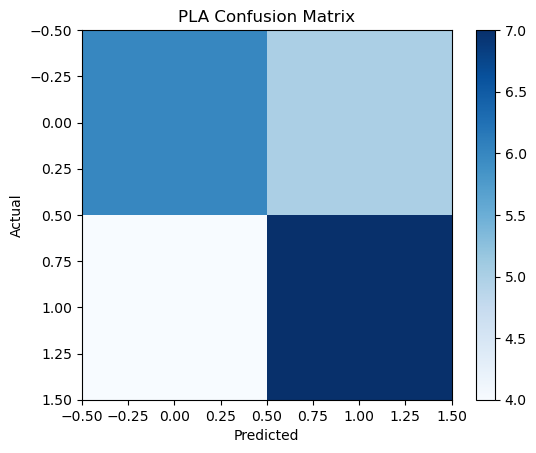

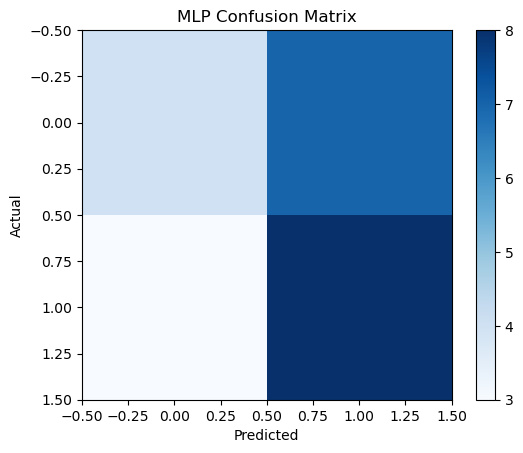

In [86]:
def plot_cm(cm, title):

    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()
    plt.show()


plot_cm(confusion_matrix(Y_test, Y_pred_pla), "PLA Confusion Matrix")
plot_cm(confusion_matrix(Y_test, Y_pred_mlp), "MLP Confusion Matrix")


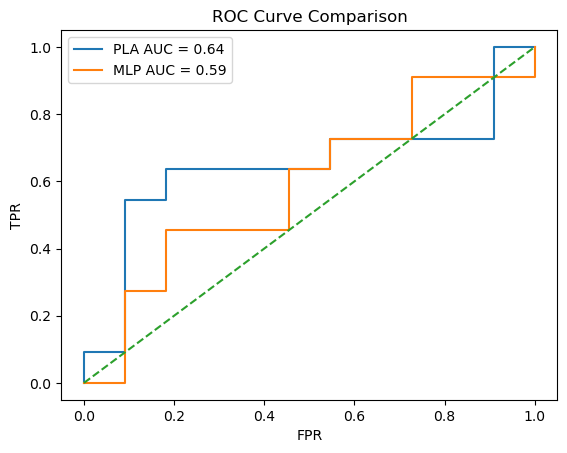

In [87]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc

lb = LabelBinarizer()
Y_test_bin = lb.fit_transform(Y_test)

# -------- PLA ROC --------
pla_scores = np.dot(X_test, pla.weights) + pla.bias

fpr_pla, tpr_pla, _ = roc_curve(Y_test, pla_scores)
auc_pla = auc(fpr_pla, tpr_pla)

# -------- MLP ROC --------
mlp_probs = best["Model"].predict_proba(X_test)[:,1]

fpr_mlp, tpr_mlp, _ = roc_curve(Y_test, mlp_probs)
auc_mlp = auc(fpr_mlp, tpr_mlp)

plt.plot(fpr_pla, tpr_pla, label=f"PLA AUC = {auc_pla:.2f}")
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP AUC = {auc_mlp:.2f}")
plt.plot([0,1],[0,1],"--")
plt.title("ROC Curve Comparison")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()


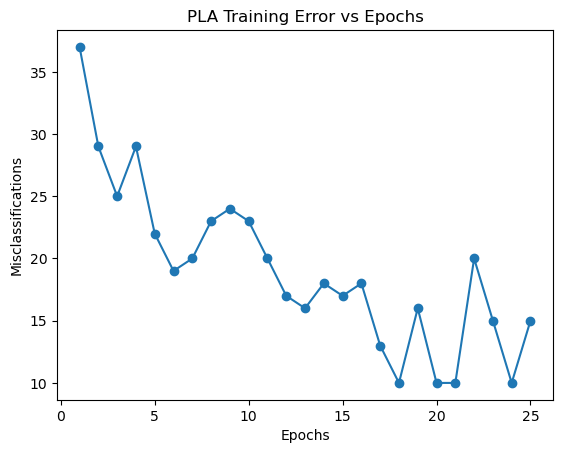

In [88]:
plt.plot(range(1,len(pla.errors)+1), pla.errors, marker="o")
plt.title("PLA Training Error vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Misclassifications")
plt.show()


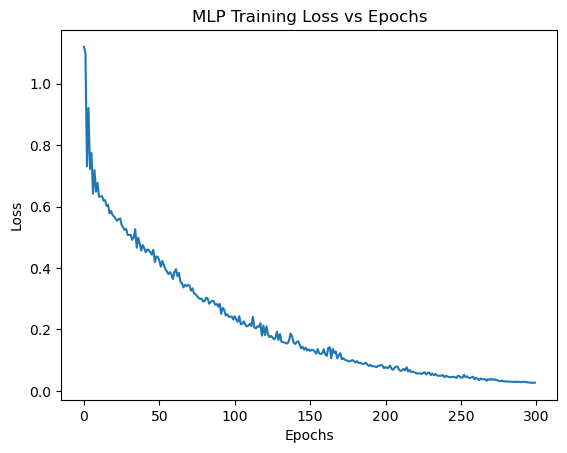

In [89]:
plt.plot(best["Model"].loss_curve_)
plt.title("MLP Training Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


In [90]:
import pandas as pd

comparison = pd.DataFrame([

    ["PLA",
     accuracy_score(Y_test, Y_pred_pla),
     precision_score(Y_test, Y_pred_pla, zero_division=0),
     recall_score(Y_test, Y_pred_pla, zero_division=0),
     f1_score(Y_test, Y_pred_pla, zero_division=0)],

    ["MLP",
     accuracy_score(Y_test, Y_pred_mlp),
     precision_score(Y_test, Y_pred_mlp, zero_division=0),
     recall_score(Y_test, Y_pred_mlp, zero_division=0),
     f1_score(Y_test, Y_pred_mlp, zero_division=0)]

], columns=["Model","Accuracy","Precision","Recall","F1"])

print(comparison)


  Model  Accuracy  Precision    Recall        F1
0   PLA  0.590909   0.583333  0.636364  0.608696
1   MLP  0.545455   0.533333  0.727273  0.615385


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load dataset
df=pd.read_csv("/Users/faatinashahul/Desktop/ml/hand/english.csv")
print(df.head())
print(df.info())
print("\nShape: ",df.shape)


]import cv2
import os
import random
BASE_DIR = "/Users/faatinashahul/Desktop/ml/hand/"

random_indices=random.sample(range(len(df)), 10)
plt.figure(figsize=(10,4))
for i,idx in enumerate(random_indices):
    img_path=os.path.join(BASE_DIR,df.iloc[i]['image'])
    label=df.iloc[i]['label']
    img=cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
    plt.subplot(2,5,i+1)
    plt.imshow(img,cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
plt.suptitle("Sample Handwritten Characters")
plt.show()

#Class distribution
plt.figure(figsize=(12,4))
df['label'].value_counts().sort_index().plot(kind='bar')
plt.title("Class distribution")
plt.xlabel("Class label")
plt.ylabel("Number of samples")
plt.show()

random_indices=random.sample(range(len(df)),20)
sizes=[]
for idx in random_indices:
    img_path=os.path.join(BASE_DIR,df.iloc[idx]['image'])
    img=cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
    if img is not None:
        sizes.append(img.shape)

print("Original image sizes(height,width):")
print(set(sizes))

IMG_SIZE=28

def preprocess_images(df):
    X=[]
    y=[]
    for i,row in df.iterrows():
        img_path=os.path.join(BASE_DIR,row['image'])
        img=cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        #crop white background
        _,thresh=cv2.threshold(img,240,255,cv2.THRESH_BINARY_INV)

        #find contours
        contours,_=cv2.findContours(
            thresh,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        if contours:
            # Get bounding box of largest contour
            c = max(contours, key=cv2.contourArea)
            x, y_coord, w, h = cv2.boundingRect(c)
            img = img[y_coord:y_coord+h, x:x+w]

        #resize cropped image
        img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))

        #normalize and flatten
        img=img/255.0
        img=img.flatten()

        X.append(img)
        y.append(row['label'])

    return np.array(X),np.array(y)

X,y=preprocess_images(df)
print("Feature matrix shape:",X.shape)
print("Label vector shape:",y.shape)

idx=np.random.randint(0, len(df))
img_path=os.path.join(BASE_DIR, df.iloc[idx]['image'])
img_original=cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_resized=cv2.resize(img_original, (IMG_SIZE, IMG_SIZE))

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img_original, cmap='gray')
plt.title("Original (900x1200)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_resized, cmap='gray')
plt.title("Resized ")
plt.axis('off')
plt.suptitle(f"Label: {df.iloc[idx]['label']}")
plt.show()

#Splitting the dataset
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size: ",X_train.shape)
print("Testing set size: ",X_test.shape)

#step activation function
def step_activation(x):
    return np.where(x>=0,1,0)

#perceptron class
class Perceptron:
    def __init__(self,lr=0.01,epochs=50):
        self.lr=lr
        self.epochs=epochs

    def fit(self,X,y):
        self.weights=np.zeros(X.shape[1])
        self.bias=0
        self.errors=[]

        for _ in range(self.epochs):
            total_error=0
            for xi,yi in zip(X,y):
                linear_output=np.dot(xi,self.weights)+self.bias
                y_hat=step_activation(linear_output)

                update=self.lr * (yi - y_hat)
                self.weights+=update*xi
                self.bias+=update
                total_error+=abs(update)

            self.errors.append(total_error)

    def score(self,X):
        return np.dot(X,self.weights)+self.bias

#One-vs-rest PLA for multi-class
classes=np.unique(y_train)
pla_models=[]

for cls in classes:
    print(f"Training PLA for class {cls}")
    y_binary=np.where(y_train==cls,1,0)

    pla=Perceptron(lr=0.01,epochs=50)
    pla.fit(X_train,y_binary)
    pla_models.append(pla)

def pla_predict(X, pla_models, classes):
    scores=[]
    for pla in pla_models:
        scores.append(pla.score(X))

    scores = np.array(scores)
    best_class_index = np.argmax(scores, axis=0)
    return classes[best_class_index]

y_pred_pla=pla_predict(X_test,pla_models,classes)

from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score

#PLA metrics
print("PLA Accuracy: ",accuracy_score(y_test,y_pred_pla))
print("PLA Precision: ",precision_score(y_test,y_pred_pla,average='macro'))
print("PLA Recall: ",recall_score(y_test,y_pred_pla,average='macro'))
print("PLA F1-score: ",f1_score(y_test,y_pred_pla,average='macro'))

#plot PLA training errors
plt.figure()
for i,pla in enumerate(pla_models[:5]):
    plt.plot(pla.errors,label=f'Class {classes[i]}')

plt.title("PLA Training Error vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Total error")
plt.legend()
plt.show()

from sklearn.metrics import confusion_matrix

# Confusion Matrix
plt.figure(figsize=(10,8))
cm = confusion_matrix(y_test, y_pred_pla, labels=classes)
plt.imshow(cm, cmap='Blues')
plt.title("PLA Confusion Matrix")
plt.colorbar()
plt.show()

from sklearn.neural_network import MLPClassifier

mlp_configs=[
{"hidden_layer_sizes":(256,128),"activation":"relu","solver":"adam","lr":0.001,"batch_size":32},
{"hidden_layer_sizes":(256,128),"activation":"relu","solver":"adam","lr":0.01,"batch_size":32},
{"hidden_layer_sizes":(256,128),"activation":"relu","solver":"adam","lr":0.001,"batch_size":64},
{"hidden_layer_sizes":(256,128),"activation":"relu","solver":"sgd","lr":0.001,"batch_size":32},
{"hidden_layer_sizes":(256,128),"activation":"tanh","solver":"adam","lr":0.001,"batch_size":32}
]

mlp_results=[]

for cfg in mlp_configs:
    mlp=MLPClassifier(
        hidden_layer_sizes=cfg["hidden_layer_sizes"],
        activation=cfg["activation"],
        solver=cfg['solver'],
        learning_rate_init=cfg['lr'],
        batch_size=cfg['batch_size'],
        max_iter=100,
        random_state=42,
        verbose=False
    )

    mlp.fit(X_train,y_train)
    y_pred_mlp=mlp.predict(X_test)

    acc=accuracy_score(y_test, y_pred_mlp)
    prec=precision_score(y_test, y_pred_mlp, average='macro')
    rec=recall_score(y_test, y_pred_mlp, average='macro')
    f1=f1_score(y_test, y_pred_mlp, average='macro')

    mlp_results.append({
        "Hidden Layers": cfg["hidden_layer_sizes"],
        "Activation": cfg["activation"],
        "Solver": cfg["solver"],
        "Learning Rate": cfg["lr"],
        "Batch Size": cfg["batch_size"],
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "Model": mlp
    })

#converting results to dataframe
mlp_df=pd.DataFrame(mlp_results)
print("All MLP configurations and Performance")
print(mlp_df.drop(columns="Model").to_string(index=False))

#select best model based on accuracy
best_mlp = mlp_results[np.argmax([res["Accuracy"] for res in mlp_results])]

print("\nBest MLP Configuration")
best_df = pd.DataFrame([best_mlp]).drop(columns="Model")
print(best_df.to_string(index=False))

# Confusion Matrix
plt.figure(figsize=(10,8))
cm = confusion_matrix(
    y_test,
    best_mlp["Model"].predict(X_test),
    labels=classes
)

plt.imshow(cm, cmap='Blues')
plt.title("MLP Confusion Matrix")
plt.colorbar()
plt.show()

from sklearn.metrics import roc_curve,auc
from sklearn.preprocessing import LabelBinarizer

#ROC curve for multi-class
y_test_bin = LabelBinarizer().fit_transform(y_test)
y_score = best_mlp["Model"].predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_bin.ravel(),
    y_score.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f'Micro-average ROC (area = {roc_auc["micro"]:.2f})',
    color='darkorange'
)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MLP ROC Curve")
plt.legend()
plt.show()

comparison = pd.DataFrame([
["PLA",
 accuracy_score(y_test, y_pred_pla),
 precision_score(y_test, y_pred_pla, average='macro'),
 recall_score(y_test, y_pred_pla, average='macro'),
 f1_score(y_test, y_pred_pla, average='macro')],
["MLP",
 best_mlp["Accuracy"],
 best_mlp["Precision"],
 best_mlp["Recall"],
 best_mlp["F1-score"]]
],
columns=["Model","Accuracy","Precision","Recall","F1-score"])

print("\nModel Comparison")
print(comparison)


                image label
0  Img/img001-001.png     0
1  Img/img001-002.png     0
2  Img/img001-003.png     0
3  Img/img001-004.png     0
4  Img/img001-005.png     0
Index(['image', 'label'], dtype='object')


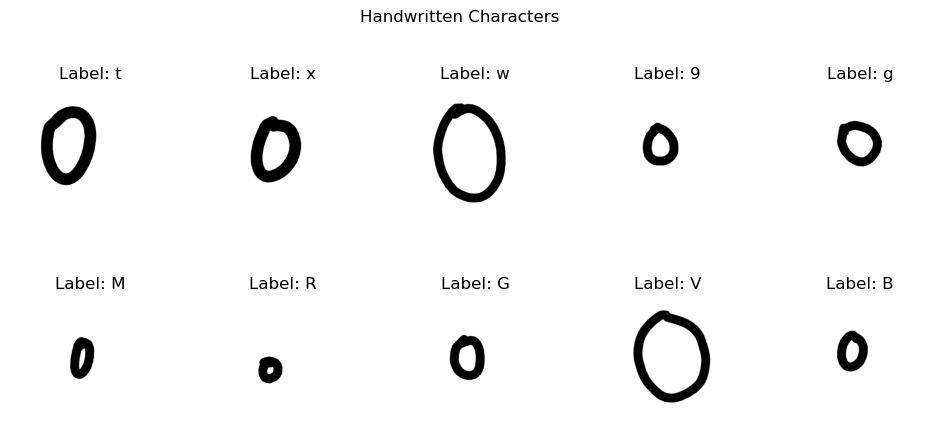

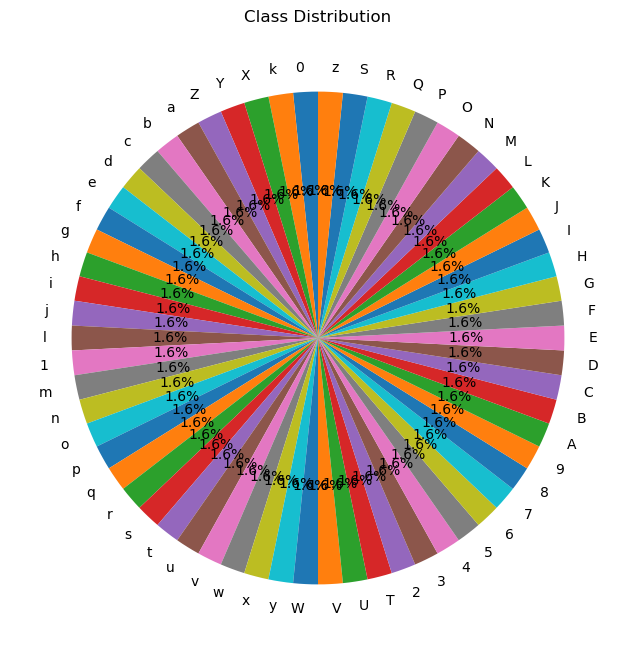

Original image sizes(height,width):
{(900, 1200)}


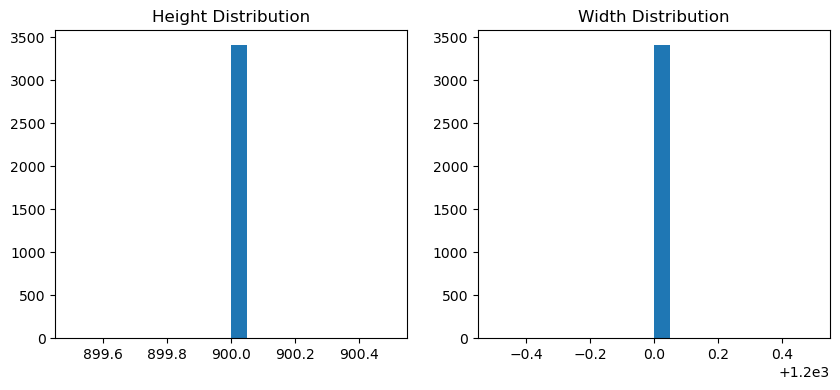

Feature matrix shape: (3410, 784)
Label vector shape: (3410,)


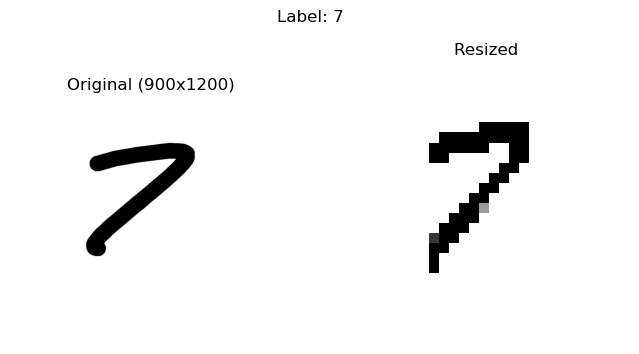

Training set size:  (2728, 784)
Testing set size:  (682, 784)
PLA Accuracy:  0.6730205278592375
PLA Precision:  0.6812653744105357
PLA Recall:  0.6730205278592375
PLA F1-score:  0.6684131192601275


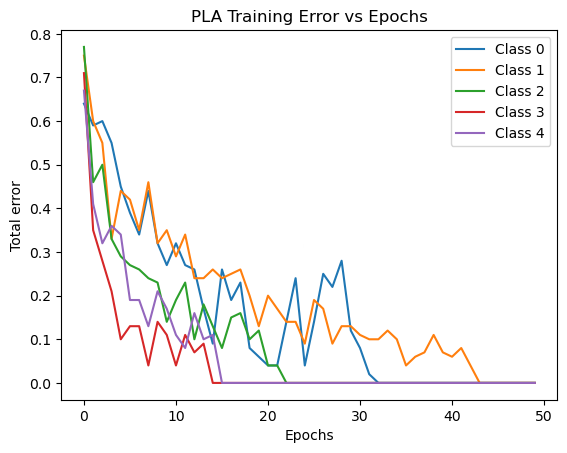

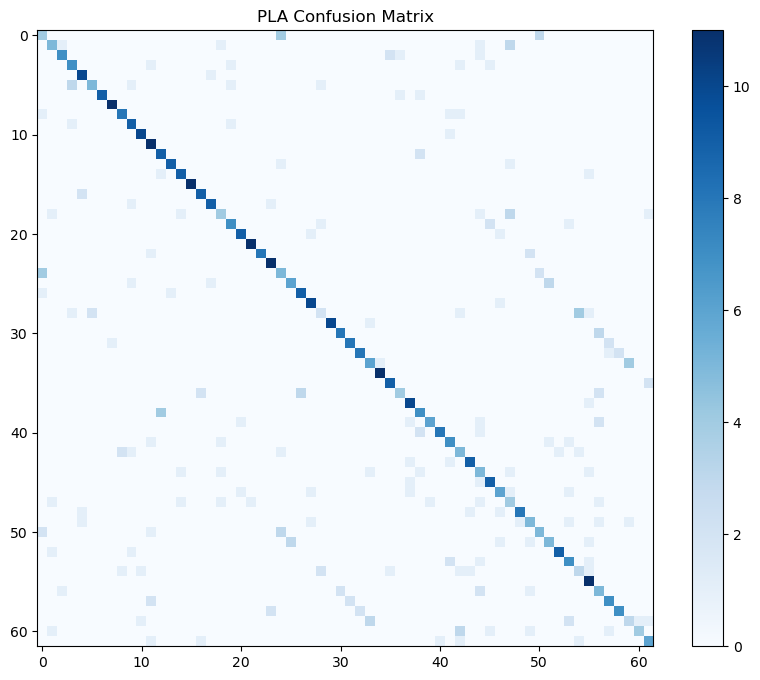

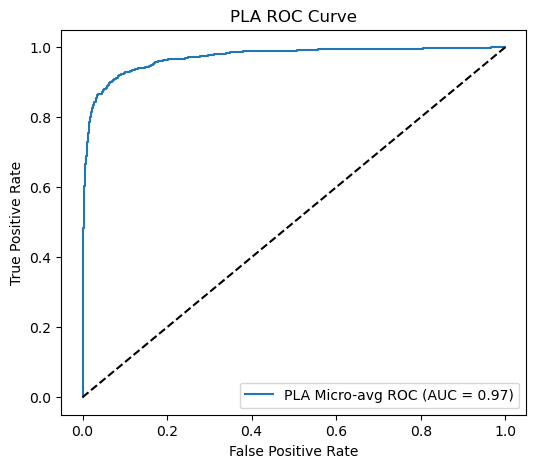